In [34]:
import os, sys
from pathlib import Path
try:
    notebook_path = globals().get('__vsc_ipynb_file__')
    if notebook_path:
        os.chdir(Path(notebook_path).parent.parent)
except Exception:
    pass
sys.path.insert(0, str(Path('.').resolve()))
sys.path.insert(0, str(Path('.').resolve().parent))
sys.path.insert(0, str(Path('.').resolve() / 'utils' / 'model_training'))
print('cwd:', os.getcwd())

cwd: /vol/bitbucket/gk225/POC_DDM/gk_code/main/multiplex


In [35]:
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import joblib

from sklearn.metrics import (
    accuracy_score, hamming_loss, f1_score,
    precision_score, recall_score, multilabel_confusion_matrix
)
from IPython.display import display

import config_multiplex as cfg
from model_utils_multilabel import ML_MODEL_KEY_MAP, ML_MODEL_PRINT_MAP

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_rows', 80)

LAB_FOLDER = Path(cfg.LAB_MULTIPLEX_FOLDER)

## Config

In [36]:
DATASET      = '01_ACA_qdPCR'
USE_10FOLD   = True     # True → _10fold.joblib
FILTER_KEY   = None     # None = no outlier filter
TARGETS      = cfg.MULTIPLEX_TARGETS   # ['KPC', 'NDM', 'VIM']

RESULTS_DIR  = LAB_FOLDER / DATASET
_file_map    = cfg.RESULT_10FOLD_FILE_BY_FLAG if USE_10FOLD else cfg.RESULT_FILE_BY_FLAG

print(f'Dataset : {DATASET}')
print(f'Targets : {TARGETS}')
for flag, fname in _file_map.items():
    p = RESULTS_DIR / fname
    print(f'  [{flag:12s}] {fname}  exists={p.exists()}')

Dataset : 01_ACA_qdPCR
Targets : ['KPC', 'NDM', 'VIM']
  [default     ] classification_performances_ml_10fold.joblib  exists=True
  [cross_attn  ] classification_performances_ml_cross_attn_10fold.joblib  exists=True
  [cattn_v2    ] classification_performances_ml_cattn_v2_10fold.joblib  exists=True
  [auxdet      ] classification_performances_ml_auxdet_10fold.joblib  exists=True
  [quercon     ] classification_performances_ml_quercon_10fold.joblib  exists=True
  [condreg     ] classification_performances_ml_condreg_10fold.joblib  exists=True


## Load & merge per-group results

In [37]:
all_results = {}
loaded_flags = []
for flag, fname in _file_map.items():
    path = RESULTS_DIR / fname
    if not path.exists():
        continue
    d = joblib.load(path)
    for fk, fv in d.items():
        all_results.setdefault(fk, {}).update(fv)
    loaded_flags.append(flag)

if not all_results:
    raise FileNotFoundError(f'No result files found in {RESULTS_DIR}. Run 03_main_training.py first.')

res = all_results.get(FILTER_KEY)
if res is None:
    raise KeyError(f'FILTER_KEY={FILTER_KEY!r} not in results. Available: {list(all_results.keys())}')

y_true = np.concatenate(res['y_trues_'], axis=0)   # (N, n_targets)
N, n_targets = y_true.shape

print(f'Groups loaded : {loaded_flags}')
print(f'N samples     : {N}')
print(f'n_targets     : {n_targets}')
for j, t in enumerate(TARGETS):
    print(f'  {t}: prevalence={y_true[:, j].mean():.3f}')

Groups loaded : ['default', 'cross_attn', 'cattn_v2', 'auxdet', 'quercon', 'condreg']
N samples     : 26571
n_targets     : 3
  KPC: prevalence=0.436
  NDM: prevalence=0.413
  VIM: prevalence=0.448


## Metric helpers

In [38]:
def _ml_metrics(res_entry, model_key):
    """Return (exact_mean, exact_std, hamming_mean, f1s_mean, f1s_std) for one model.
    Returns all-None tuple if the model has no results.
    """
    preds_key, probs_key, _ = ML_MODEL_KEY_MAP[model_key]
    if preds_key not in res_entry or 'y_trues_' not in res_entry:
        return None, None, None, None, None
    exact, ham, f1s = [], [], []
    for yt, yp in zip(res_entry['y_trues_'], res_entry[preds_key]):
        yt, yp = np.array(yt), np.array(yp)
        exact.append(accuracy_score(yt, yp))
        ham.append(1.0 - hamming_loss(yt, yp))
        f1s.append(f1_score(yt, yp, average='samples', zero_division=0))
    return (np.mean(exact)*100, np.std(exact)*100,
            np.mean(ham)*100,
            np.mean(f1s)*100, np.std(f1s)*100)


def _per_label_metrics(res_entry, model_key):
    """Return (precision, recall, f1) arrays of shape (n_targets,)."""
    preds_key, _, _ = ML_MODEL_KEY_MAP[model_key]
    if preds_key not in res_entry:
        return None, None, None
    yt_all = np.concatenate(res_entry['y_trues_'], axis=0)
    yp_all = np.concatenate(res_entry[preds_key], axis=0)
    p = precision_score(yt_all, yp_all, average=None, zero_division=0)
    r = recall_score(yt_all, yp_all, average=None, zero_division=0)
    f = f1_score(yt_all, yp_all, average=None, zero_division=0)
    return p, r, f


def _collect_all(res_entry):
    """Return DataFrame with one row per model that has results."""
    rows = []
    for m in cfg.MULTIPLEX_MODELS:
        em, es, hm, f1m, f1s = _ml_metrics(res_entry, m)
        if em is None:
            continue
        rows.append(dict(
            key=m,
            label=ML_MODEL_PRINT_MAP.get(m, m),
            flag=cfg.MODEL_FLAG_MAP.get(m, '?'),
            exact_mean=em, exact_std=es,
            hamming_mean=hm,
            f1s_mean=f1m, f1s_std=f1s,
        ))
    return pd.DataFrame(rows)


df_all = _collect_all(res)
print(f'Models with results: {len(df_all)}')

Models with results: 59


---
## Section 1 · Leaderboard

In [39]:
df_lb = df_all.sort_values('exact_mean', ascending=False).reset_index(drop=True)
df_lb.index += 1

display(
    df_lb[['label', 'flag', 'exact_mean', 'exact_std', 'hamming_mean', 'f1s_mean', 'f1s_std']]
    .rename(columns={
        'exact_mean': 'Exact %', 'exact_std': '±',
        'hamming_mean': 'Hamming %', 'f1s_mean': 'F1-samp %', 'f1s_std': '±.1',
    })
    .style.format({
        'Exact %': '{:.2f}', '±': '{:.2f}',
        'Hamming %': '{:.2f}', 'F1-samp %': '{:.2f}', '±.1': '{:.2f}',
    })
    .background_gradient(subset=['Exact %'], cmap='RdYlGn')
    .set_caption(f'Leaderboard — {DATASET} (sorted by Exact Match)')
)

,label,flag,Exact %,±,Hamming %,F1-samp %,±.1
1,CNN+GRU SC2,default,82.44,0.85,92.09,93.17,0.32
2,CNN+Tr CAttn-V2 SC2,cattn_v2,81.18,1.47,91.60,92.66,0.77
3,Trans RCFD CGD SC1,condreg,81.10,1.00,91.55,92.69,0.33
4,CNN+Tr CAttn SC1,cross_attn,81.05,1.24,91.65,92.71,0.62
5,CNN+Tr CAttn SC3,cross_attn,81.04,1.41,91.69,92.69,0.69
6,CNN+Tr CAttn-V2 SC1,cattn_v2,80.99,1.34,91.45,92.57,0.53
7,CNN+GRU SC1,default,80.76,0.80,91.46,92.59,0.30
8,CNN+Tr CAttn SC2,cross_attn,80.55,0.89,91.55,92.66,0.26
9,GRU RCFD CGD SC2,condreg,80.31,2.39,91.31,92.36,0.85
10,CNN+GRU CAttn-V2 AuxDet SC1,auxdet,80.23,1.24,91.23,92.31,0.59


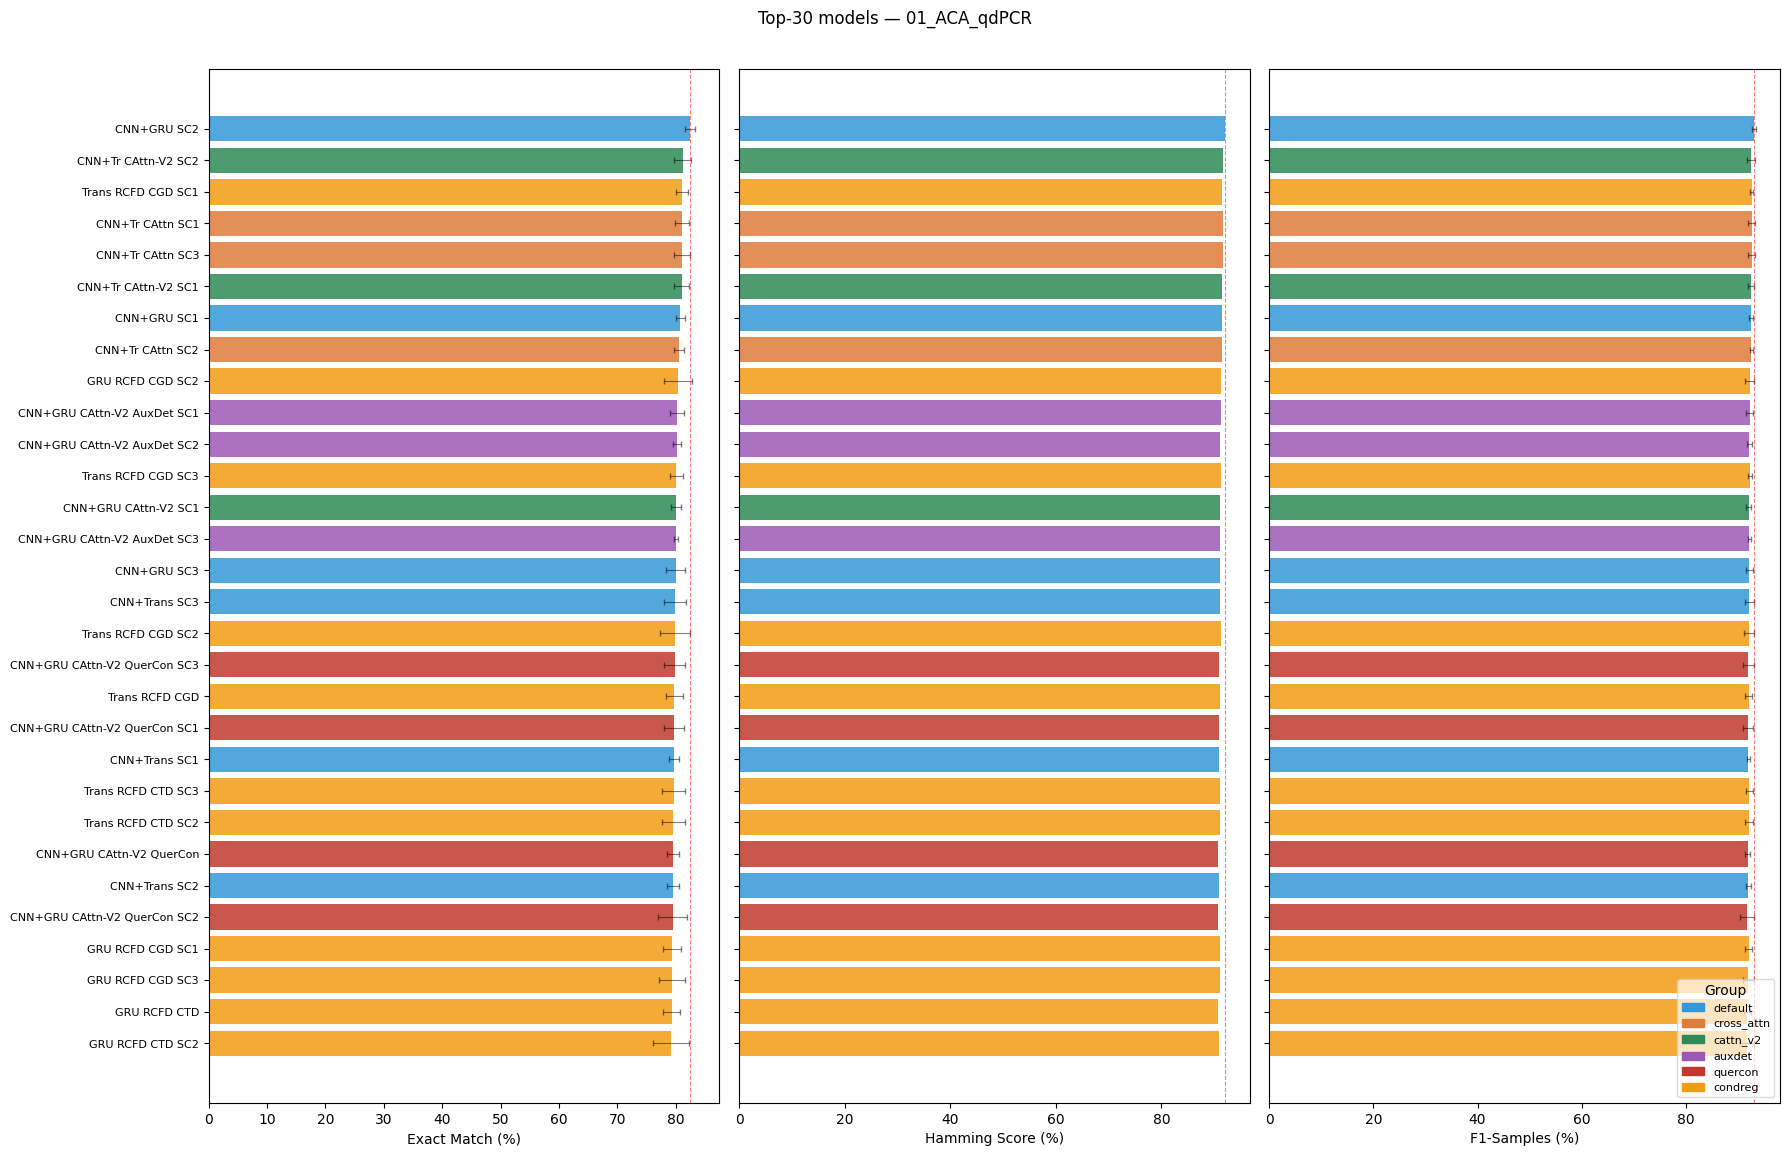

In [40]:
# Horizontal bar chart: top-N by exact match
TOP_N = min(30, len(df_lb))
df_top = df_lb.head(TOP_N).sort_values('exact_mean')

_flag_colors = {
    'default':    '#3498d8',
    'cross_attn': '#e07c39',
    'cattn_v2':   '#2e8b57',
    'auxdet':     '#9b59b6',
    'quercon':    '#c0392b',
    'condreg':    '#f39c12',
}

fig, axes = plt.subplots(1, 3, figsize=(18, max(5, TOP_N * 0.38)), sharey=True)
metrics   = [('exact_mean', 'exact_std', 'Exact Match (%)'),
             ('hamming_mean', None, 'Hamming Score (%)'),
             ('f1s_mean', 'f1s_std', 'F1-Samples (%)')]

for ax, (mcol, scol, mlabel) in zip(axes, metrics):
    colors = [_flag_colors.get(f, '#888') for f in df_top['flag']]
    xerr   = df_top[scol].values if scol else None
    ax.barh(df_top['label'], df_top[mcol], xerr=xerr,
            color=colors, alpha=0.85, capsize=2,
            error_kw={'linewidth': 0.8, 'alpha': 0.5})
    ax.set_xlabel(mlabel, fontsize=10)
    ax.axvline(df_top[mcol].max(), color='red', lw=0.8, ls='--', alpha=0.5)
    ax.tick_params(axis='y', labelsize=8)

# Legend for group colours
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=f) for f, c in _flag_colors.items()]
axes[-1].legend(handles=legend_handles, title='Group', fontsize=8,
                loc='lower right', framealpha=0.7)

fig.suptitle(f'Top-{TOP_N} models — {DATASET}', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

---
## Section 2 · Family × SC Heatmap

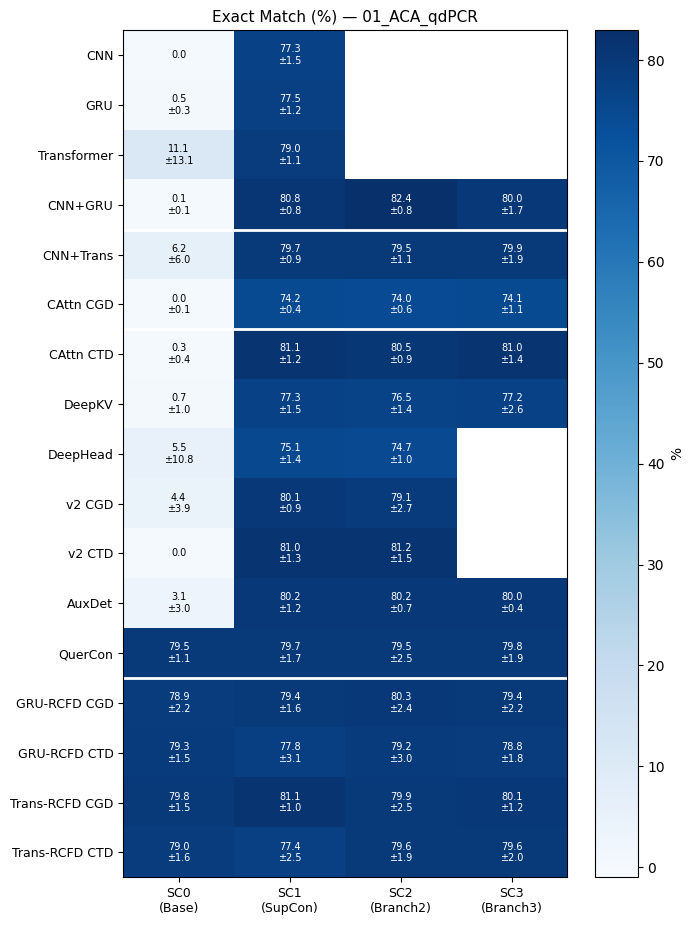

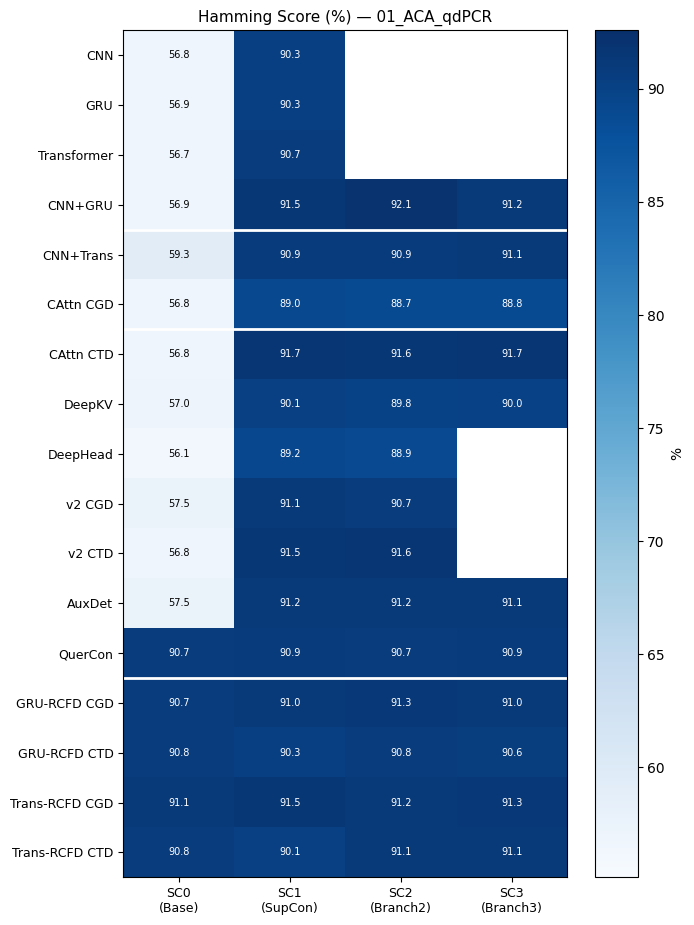

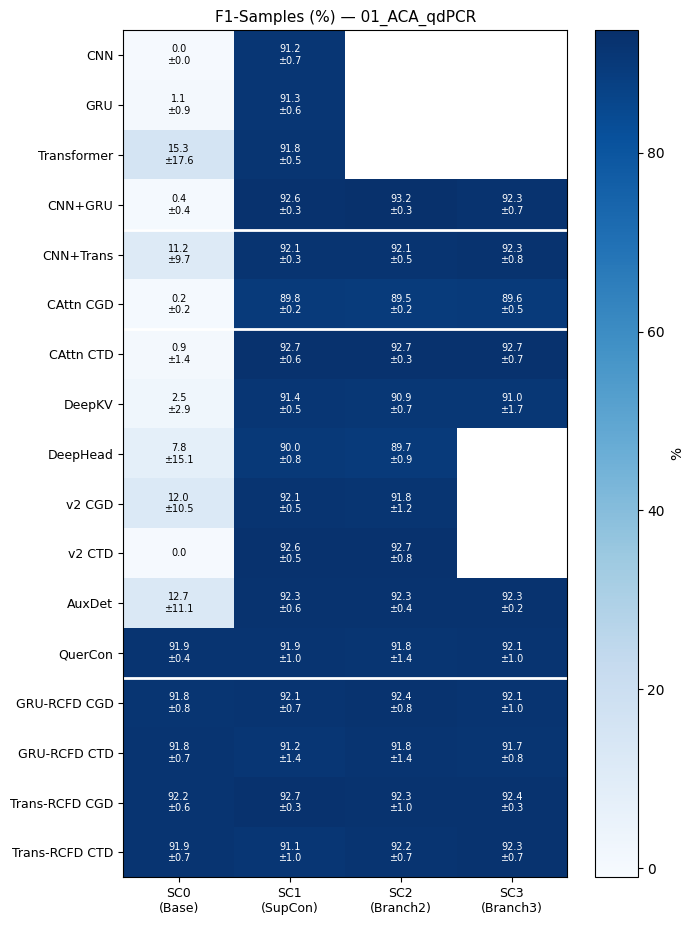

In [41]:
# Rows = model family (base key without SC suffix)
# Cols = SC level 0-3
# Cell = exact match mean %

_FAMILY_ROWS = [
    ('CNN',             'cnn',                       False),
    ('GRU',             'gru',                       False),
    ('Transformer',     'transformer',               False),
    ('CNN+GRU',         'cnn_gru_dual',              False),
    ('CNN+Trans',       'cnn_trans_dual',            False),
    ('CAttn CGD',       'cnn_gru_dual_cross_attn',   False),
    ('CAttn CTD',       'cnn_trans_dual_cross_attn', False),
    ('DeepKV',          'cnn_gru_dual_cross_attn_deepkv',  False),
    ('DeepHead',        'cnn_gru_dual_cross_attn_deephead',False),
    ('v2 CGD',          'cnn_gru_dual_cross_attn_v2',      False),
    ('v2 CTD',          'cnn_trans_dual_cross_attn_v2',    False),
    ('AuxDet',          'cnn_gru_dual_cross_attn_v2_auxdet',   False),
    ('QuerCon',         'cnn_gru_dual_cross_attn_v2_quercon',  False),
    ('GRU-RCFD CGD',    'gru_rcfd_cgd',   True),
    ('GRU-RCFD CTD',    'gru_rcfd_ctd',   True),
    ('Trans-RCFD CGD',  'trans_rcfd_cgd', True),
    ('Trans-RCFD CTD',  'trans_rcfd_ctd', True),
]

def _sc_key(base, sc, is_rcfd):
    """Resolve model key for (base, sc_level)."""
    if sc == 0:
        return base
    if is_rcfd:
        sfx = {1: '_supcon_mtl', 2: '_supcon2_mtl', 3: '_supcon3_mtl'}[sc]
    else:
        sfx = {1: '_supcon', 2: '_supcon2', 3: '_supcon3'}[sc]
    return base + sfx


def plot_family_sc_heatmap(res_entry, metric='exact', title=''):
    """Heatmap: model family (rows) × SC level (cols)."""
    n_rows = len(_FAMILY_ROWS)
    n_cols = 4
    mat    = np.full((n_rows, n_cols), np.nan)
    mat_s  = np.full_like(mat, np.nan)

    for ri, (_, base, is_rcfd) in enumerate(_FAMILY_ROWS):
        for sc in range(4):
            key = _sc_key(base, sc, is_rcfd)
            if key not in ML_MODEL_KEY_MAP:
                continue
            em, es, hm, f1m, f1s = _ml_metrics(res_entry, key)
            if em is None:
                continue
            val = {'exact': (em, es), 'hamming': (hm, None), 'f1s': (f1m, f1s)}[metric]
            mat[ri, sc]   = val[0]
            mat_s[ri, sc] = val[1] if val[1] is not None else 0.0

    if np.all(np.isnan(mat)):
        print('[!] No results to plot.'); return

    vmin = np.nanmin(mat) - 1
    vmax = np.nanmax(mat) + 0.5

    fig, ax = plt.subplots(figsize=(7, max(5, n_rows * 0.55)))
    im = ax.imshow(mat, cmap='Blues', vmin=vmin, vmax=vmax, aspect='auto')
    plt.colorbar(im, ax=ax, label='%')

    ax.set_xticks(range(4))
    ax.set_xticklabels(['SC0\n(Base)', 'SC1\n(SupCon)', 'SC2\n(Branch2)', 'SC3\n(Branch3)'],
                       fontsize=9)
    ax.set_yticks(range(n_rows))
    ax.set_yticklabels([r for r, _, _ in _FAMILY_ROWS], fontsize=9)

    # Group separators
    separator_rows = [4, 6, 13]  # after ST, after cross_attn, before RCFD
    for sr in separator_rows:
        ax.axhline(sr - 0.5, color='white', lw=2)

    # Annotate cells
    for ri in range(n_rows):
        for ci in range(n_cols):
            v = mat[ri, ci]
            s = mat_s[ri, ci]
            if np.isnan(v):
                continue
            txt = f'{v:.1f}'
            if not np.isnan(s) and s > 0:
                txt += f'\n±{s:.1f}'
            brightness = (v - vmin) / (vmax - vmin)
            color = 'white' if brightness > 0.6 else 'black'
            ax.text(ci, ri, txt, ha='center', va='center', fontsize=7, color=color)

    metric_label = {'exact': 'Exact Match', 'hamming': 'Hamming Score', 'f1s': 'F1-Samples'}[metric]
    ax.set_title(f'{metric_label} (%) — {title or DATASET}', fontsize=11)
    plt.tight_layout()
    plt.show()


for metric in ['exact', 'hamming', 'f1s']:
    plot_family_sc_heatmap(res, metric=metric)

---
## Section 3 · Cross-Attention v2 Ablation

2×2 factorial: **kv_seq depth** (shallow / deep) × **head depth** (1 CA block / 2 CA + FFN).  
Plus CTD variant for the fully-combined v2.

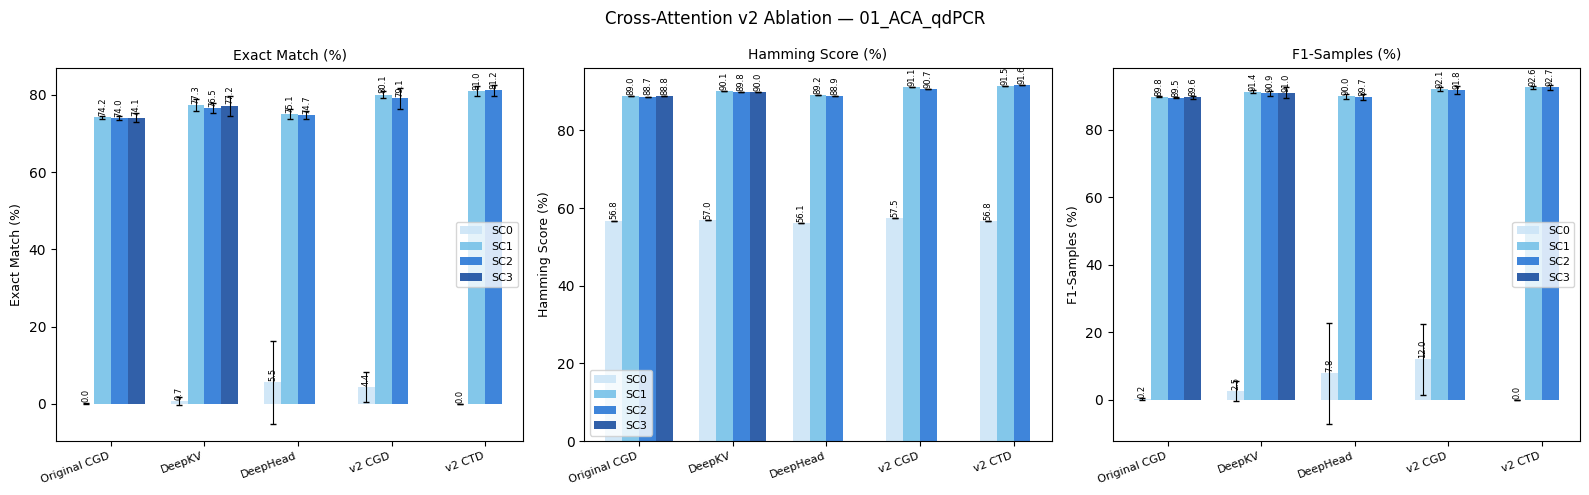

In [42]:
_ABLATION_VARIANTS = [
    ('Original CGD',  'cnn_gru_dual_cross_attn'),
    ('DeepKV',        'cnn_gru_dual_cross_attn_deepkv'),
    ('DeepHead',      'cnn_gru_dual_cross_attn_deephead'),
    ('v2 CGD',        'cnn_gru_dual_cross_attn_v2'),
    ('v2 CTD',        'cnn_trans_dual_cross_attn_v2'),
]

def plot_ca_ablation(res_entry):
    """Bar chart: variant × SC level for each metric."""
    sc_labels   = ['SC0', 'SC1', 'SC2', 'SC3']
    sc_colors   = ['#cce5f7', '#76c1e8', '#2a78d6', '#1a4fa0']
    metric_keys = [('exact', 'Exact Match (%)'), ('hamming', 'Hamming Score (%)'), ('f1s', 'F1-Samples (%)')]

    is_rcfd_map = {base: False for _, base in _ABLATION_VARIANTS}

    fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

    for ax, (metric, mlabel) in zip(axes, metric_keys):
        n_var = len(_ABLATION_VARIANTS)
        n_sc  = 4
        w     = 0.18
        x     = np.arange(n_var)
        sc_offsets = (np.arange(n_sc) - (n_sc - 1) / 2) * w

        any_data = False
        for si in range(n_sc):
            xs, ms, ss = [], [], []
            for vi, (vlabel, base) in enumerate(_ABLATION_VARIANTS):
                key = _sc_key(base, si, False)
                if key not in ML_MODEL_KEY_MAP:
                    continue
                em, es, hm, f1m, f1s = _ml_metrics(res_entry, key)
                val = {'exact': (em, es), 'hamming': (hm, 0), 'f1s': (f1m, f1s)}[metric]
                if val[0] is None:
                    continue
                xs.append(vi); ms.append(val[0]); ss.append(val[1] or 0)
                any_data = True

            if not ms:
                continue
            bars = ax.bar(np.array(xs) + sc_offsets[si], ms, w,
                          yerr=ss, label=sc_labels[si],
                          color=sc_colors[si], alpha=0.9,
                          capsize=2, error_kw={'linewidth': 0.8})
            for bar, mv in zip(bars, ms):
                ax.text(bar.get_x() + w / 2, mv + 0.3, f'{mv:.1f}',
                        ha='center', va='bottom', fontsize=6, rotation=90)

        ax.set_xticks(x)
        ax.set_xticklabels([v for v, _ in _ABLATION_VARIANTS], rotation=20, ha='right', fontsize=8)
        ax.set_ylabel(mlabel, fontsize=9)
        ax.set_title(mlabel, fontsize=10)
        if any_data:
            ax.legend(fontsize=8)

    fig.suptitle(f'Cross-Attention v2 Ablation — {DATASET}', fontsize=12)
    plt.tight_layout()
    plt.show()


plot_ca_ablation(res)

---
## Section 4 · AuxDet vs QuerCon vs v2 Baseline

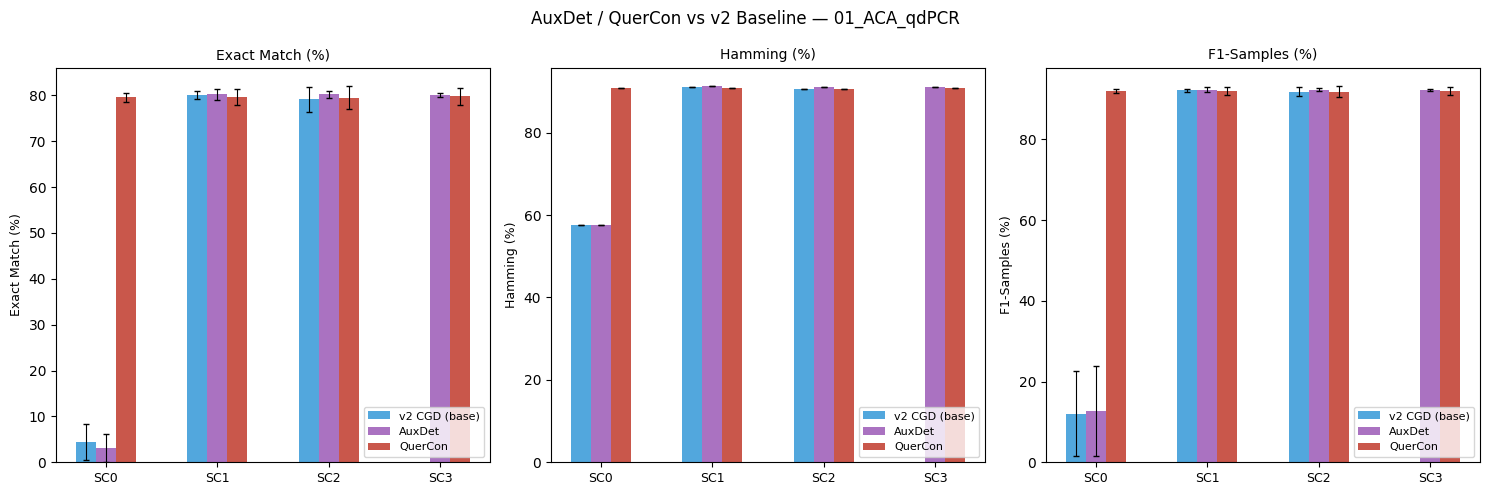

In [43]:
_LOSS_VARIANTS = [
    ('v2 CGD (base)',   'cnn_gru_dual_cross_attn_v2'),
    ('AuxDet',          'cnn_gru_dual_cross_attn_v2_auxdet'),
    ('QuerCon',         'cnn_gru_dual_cross_attn_v2_quercon'),
]
_LOSS_COLORS = ['#3498d8', '#9b59b6', '#c0392b']
sc_labels_loss = ['SC0', 'SC1', 'SC2', 'SC3']
sc_alphas      = [0.45, 0.6, 0.8, 1.0]

# AuxDet uses _supcon suffixes; QuerCon uses _quercon_supcon suffixes — handled by _sc_key
def plot_loss_variant_comparison(res_entry):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    metric_keys = [('exact', 'Exact Match (%)'), ('hamming', 'Hamming (%)'), ('f1s', 'F1-Samples (%)')]

    for ax, (metric, mlabel) in zip(axes, metric_keys):
        n_var = len(_LOSS_VARIANTS)
        n_sc  = 4
        w     = 0.18
        x     = np.arange(n_sc)
        var_offsets = (np.arange(n_var) - (n_var - 1) / 2) * w

        for vi, (vlabel, base) in enumerate(_LOSS_VARIANTS):
            # QuerCon SC1/2/3 keys have _quercon_supcon suffix pattern
            xs, ms, ss = [], [], []
            for si in range(4):
                key = _sc_key(base, si, False)
                if key not in ML_MODEL_KEY_MAP:
                    continue
                em, es, hm, f1m, f1s = _ml_metrics(res_entry, key)
                val = {'exact': (em, es), 'hamming': (hm, 0), 'f1s': (f1m, f1s)}[metric]
                if val[0] is None:
                    continue
                xs.append(si); ms.append(val[0]); ss.append(val[1] or 0)

            if not ms:
                continue
            bars = ax.bar(np.array(xs) + var_offsets[vi], ms, w,
                          yerr=ss, label=vlabel,
                          color=_LOSS_COLORS[vi], alpha=0.85,
                          capsize=2, error_kw={'linewidth': 0.8})

        ax.set_xticks(range(4))
        ax.set_xticklabels(sc_labels_loss, fontsize=9)
        ax.set_ylabel(mlabel, fontsize=9)
        ax.set_title(mlabel, fontsize=10)
        ax.legend(fontsize=8)

    fig.suptitle(f'AuxDet / QuerCon vs v2 Baseline — {DATASET}', fontsize=12)
    plt.tight_layout()
    plt.show()


plot_loss_variant_comparison(res)

---
## Section 5 · Per-Label Performance

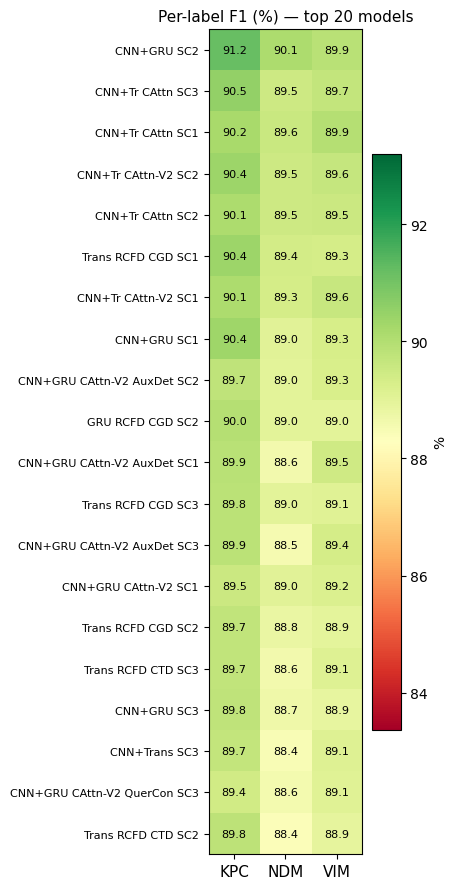

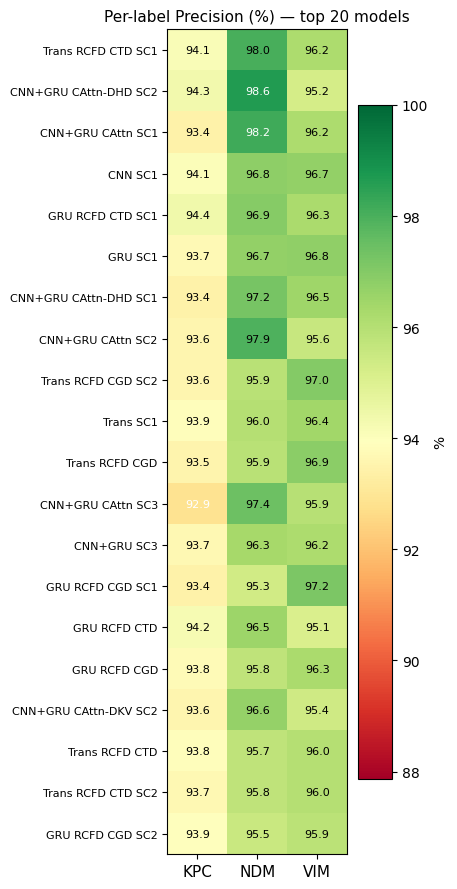

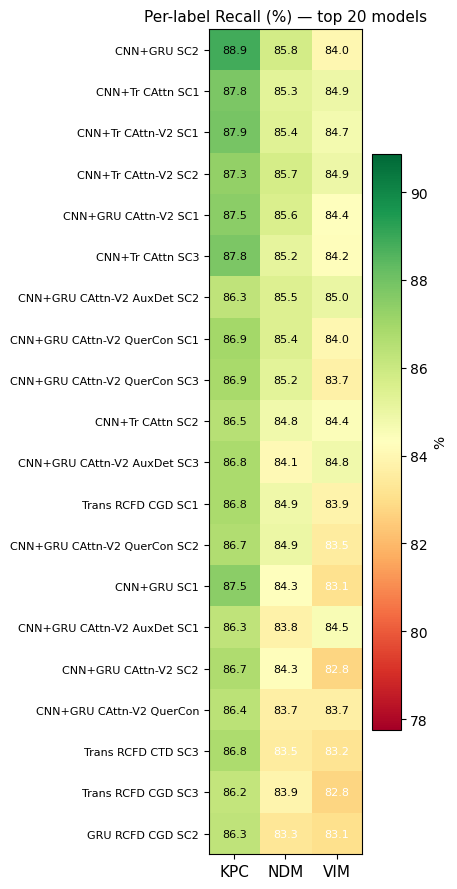

In [44]:
def plot_per_label_heatmap(res_entry, metric='f1', top_n=20):
    """Heatmap: top-N models (rows) × targets (cols) for per-label metric."""
    rows = []
    for m in cfg.MULTIPLEX_MODELS:
        p, r, f = _per_label_metrics(res_entry, m)
        if f is None:
            continue
        val = {'f1': f, 'precision': p, 'recall': r}[metric]
        rows.append({'key': m,
                     'label': ML_MODEL_PRINT_MAP.get(m, m),
                     'mean': val.mean(),
                     **{TARGETS[j]: val[j] for j in range(len(TARGETS))}})

    if not rows:
        print('[!] No results.'); return

    df_pl = pd.DataFrame(rows).sort_values('mean', ascending=False).head(top_n)
    mat   = df_pl[TARGETS].values * 100

    fig, ax = plt.subplots(figsize=(max(4, len(TARGETS) * 1.5), max(5, len(df_pl) * 0.45)))
    im = ax.imshow(mat, cmap='RdYlGn', vmin=max(0, mat[~np.isnan(mat)].min() - 5),
                   vmax=min(100, mat[~np.isnan(mat)].max() + 2), aspect='auto')
    plt.colorbar(im, ax=ax, label='%')

    ax.set_xticks(range(len(TARGETS)))
    ax.set_xticklabels(TARGETS, fontsize=11)
    ax.set_yticks(range(len(df_pl)))
    ax.set_yticklabels(df_pl['label'].tolist(), fontsize=8)

    for ri in range(len(df_pl)):
        for ci in range(len(TARGETS)):
            v = mat[ri, ci]
            brightness = (v - im.norm.vmin) / (im.norm.vmax - im.norm.vmin)
            ax.text(ci, ri, f'{v:.1f}', ha='center', va='center',
                    fontsize=8, color='white' if brightness < 0.45 or brightness > 0.85 else 'black')

    metric_label = {'f1': 'F1', 'precision': 'Precision', 'recall': 'Recall'}[metric]
    ax.set_title(f'Per-label {metric_label} (%) — top {top_n} models', fontsize=11)
    plt.tight_layout()
    plt.show()


for metric in ['f1', 'precision', 'recall']:
    plot_per_label_heatmap(res, metric=metric, top_n=20)

---
## Section 6 · SupCon Gain (SC0 → best SC)

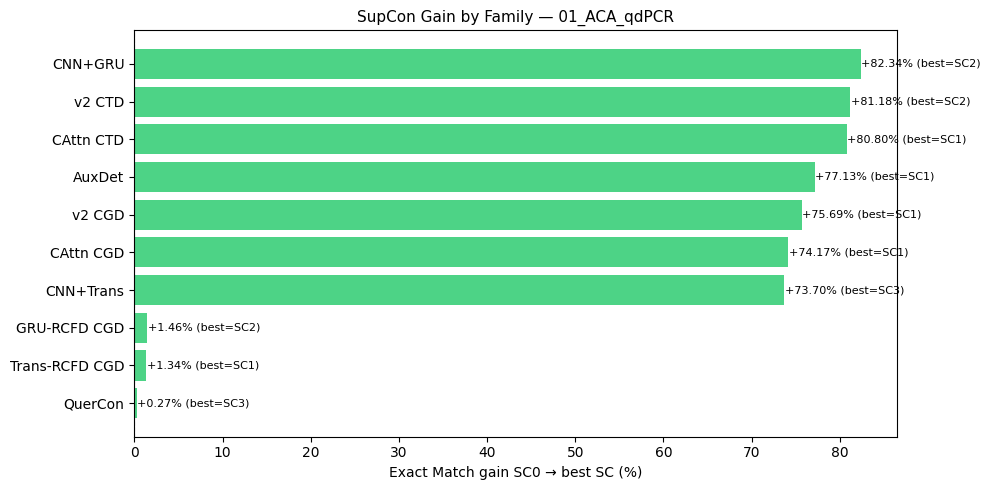

,family,sc0,best,best_sc,gain
7,QuerCon,79.55,79.82,3,+0.27
9,Trans-RCFD CGD,79.76,81.10,1,+1.34
8,GRU-RCFD CGD,78.85,80.31,2,+1.46
1,CNN+Trans,6.19,79.90,3,+73.70
2,CAttn CGD,0.04,74.20,1,+74.17
4,v2 CGD,4.38,80.07,1,+75.69
6,AuxDet,3.10,80.23,1,+77.13
3,CAttn CTD,0.26,81.05,1,+80.80
5,v2 CTD,0.00,81.18,2,+81.18
0,CNN+GRU,0.10,82.44,2,+82.34


In [45]:
_BASE_FAMILIES = [
    ('CNN+GRU',             'cnn_gru_dual',                    False),
    ('CNN+Trans',           'cnn_trans_dual',                  False),
    ('CAttn CGD',           'cnn_gru_dual_cross_attn',         False),
    ('CAttn CTD',           'cnn_trans_dual_cross_attn',       False),
    ('v2 CGD',              'cnn_gru_dual_cross_attn_v2',      False),
    ('v2 CTD',              'cnn_trans_dual_cross_attn_v2',    False),
    ('AuxDet',              'cnn_gru_dual_cross_attn_v2_auxdet',    False),
    ('QuerCon',             'cnn_gru_dual_cross_attn_v2_quercon',   False),
    ('GRU-RCFD CGD',        'gru_rcfd_cgd',                   True),
    ('Trans-RCFD CGD',      'trans_rcfd_cgd',                 True),
]

rows_gain = []
for label, base, is_rcfd in _BASE_FAMILIES:
    sc0_key = _sc_key(base, 0, is_rcfd)
    if sc0_key not in ML_MODEL_KEY_MAP:
        continue
    sc0 = _ml_metrics(res, sc0_key)
    if sc0[0] is None:
        continue

    best_sc, best_val = 0, sc0[0]
    for sc in [1, 2, 3]:
        key = _sc_key(base, sc, is_rcfd)
        if key not in ML_MODEL_KEY_MAP:
            continue
        m = _ml_metrics(res, key)
        if m[0] is not None and m[0] > best_val:
            best_val, best_sc = m[0], sc

    gain = best_val - sc0[0]
    rows_gain.append(dict(family=label, sc0=sc0[0], best=best_val,
                          best_sc=best_sc, gain=gain))

df_gain = pd.DataFrame(rows_gain).sort_values('gain', ascending=True)

fig, ax = plt.subplots(figsize=(10, max(4, len(df_gain) * 0.5)))
colors = ['#2ecc71' if g >= 0 else '#e74c3c' for g in df_gain['gain']]
bars = ax.barh(df_gain['family'], df_gain['gain'], color=colors, alpha=0.85)
for bar, row in zip(bars, df_gain.itertuples()):
    sign = '+' if row.gain >= 0 else ''
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{sign}{row.gain:.2f}% (best=SC{row.best_sc})',
            va='center', fontsize=8)
ax.axvline(0, color='grey', lw=0.8, ls='--')
ax.set_xlabel('Exact Match gain SC0 → best SC (%)', fontsize=10)
ax.set_title(f'SupCon Gain by Family — {DATASET}', fontsize=11)
plt.tight_layout()
plt.show()

display(df_gain.style.format({'sc0': '{:.2f}', 'best': '{:.2f}', 'gain': '{:+.2f}'}))

---
## Section 7 · Label Co-occurrence in Predictions

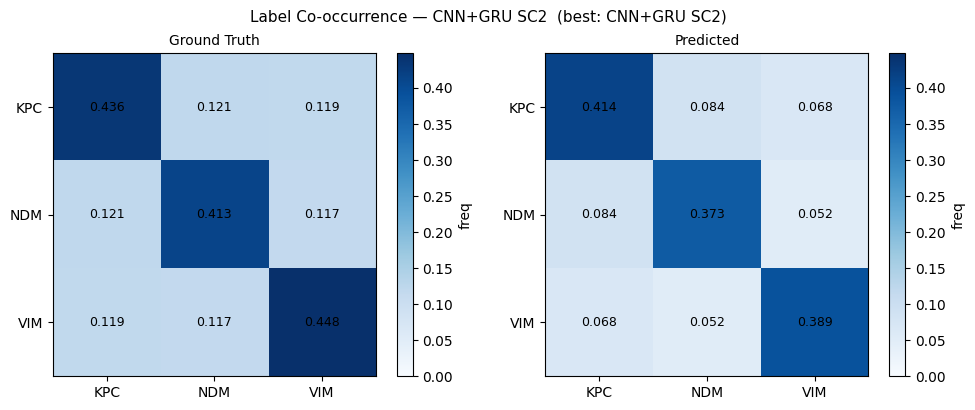

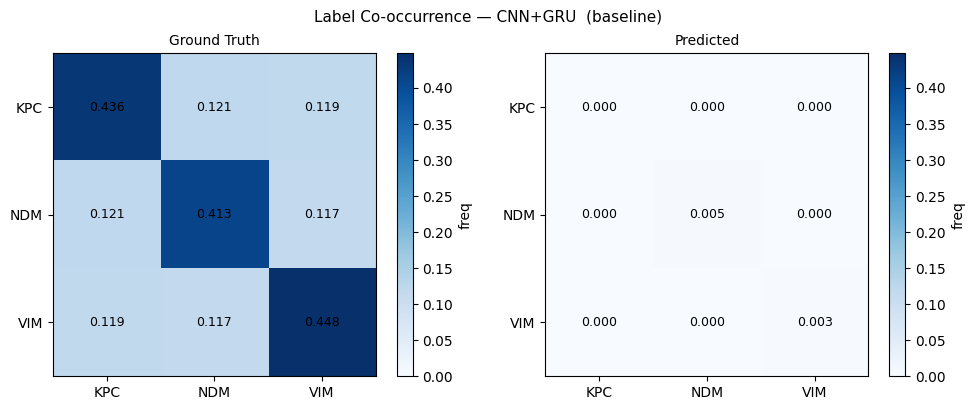

In [46]:
def plot_cooccurrence(res_entry, model_key, title=''):
    """Side-by-side co-occurrence matrix: ground truth vs predicted."""
    preds_key, _, _ = ML_MODEL_KEY_MAP[model_key]
    if preds_key not in res_entry:
        print(f'[!] {model_key} not in results'); return
    yt = np.concatenate(res_entry['y_trues_'],    axis=0)  # (N, L)
    yp = np.concatenate(res_entry[preds_key], axis=0)  # (N, L)
    L  = yt.shape[1]

    def _cooccur(y):
        mat = np.zeros((L, L), dtype=float)
        for i in range(L):
            for j in range(L):
                mat[i, j] = (y[:, i] * y[:, j]).sum() / len(y)
        return mat

    mat_true = _cooccur(yt)
    mat_pred = _cooccur(yp)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    for ax, mat, panel in zip(axes, [mat_true, mat_pred], ['Ground Truth', 'Predicted']):
        im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=mat_true.max())
        plt.colorbar(im, ax=ax, label='freq')
        ax.set_xticks(range(L)); ax.set_xticklabels(TARGETS)
        ax.set_yticks(range(L)); ax.set_yticklabels(TARGETS)
        for i in range(L):
            for j in range(L):
                ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center', fontsize=9)
        ax.set_title(f'{panel}', fontsize=10)

    model_label = ML_MODEL_PRINT_MAP.get(model_key, model_key)
    fig.suptitle(f'Label Co-occurrence — {model_label}  ({title or DATASET})', fontsize=11)
    plt.tight_layout()
    plt.show()


# Show best model + CNN+GRU baseline
best_key = df_all.sort_values('exact_mean', ascending=False).iloc[0]['key']
plot_cooccurrence(res, best_key, title=f'best: {ML_MODEL_PRINT_MAP.get(best_key, best_key)}')
if 'cnn_gru_dual' in ML_MODEL_KEY_MAP and ML_MODEL_KEY_MAP['cnn_gru_dual'][0] in res:
    plot_cooccurrence(res, 'cnn_gru_dual', title='baseline')

---
## Section 8 · RCFD vs Dual-Backbone Baseline

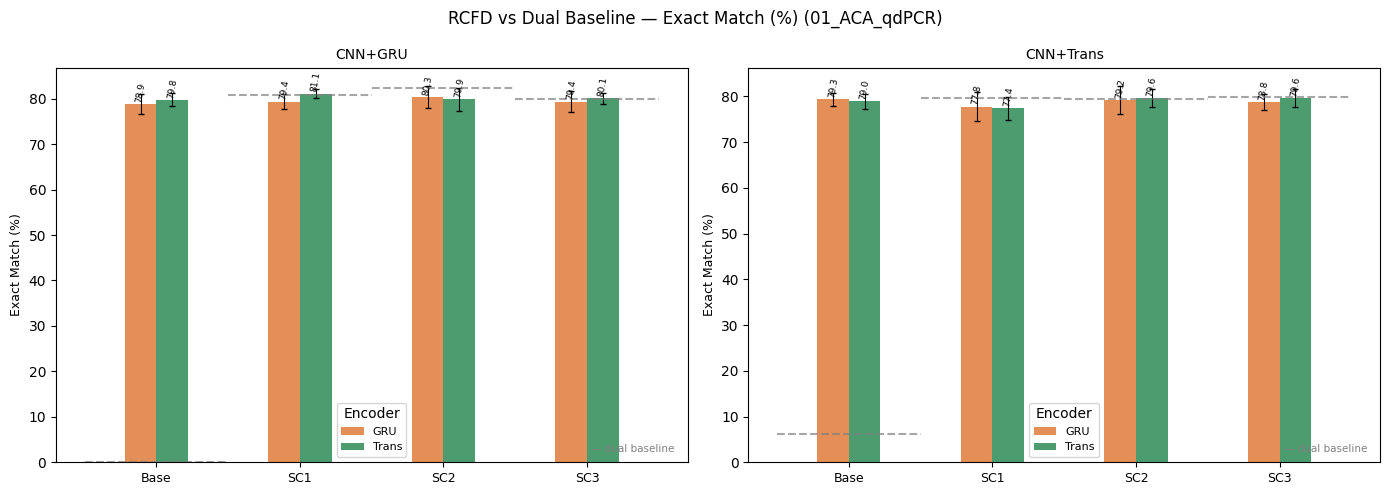

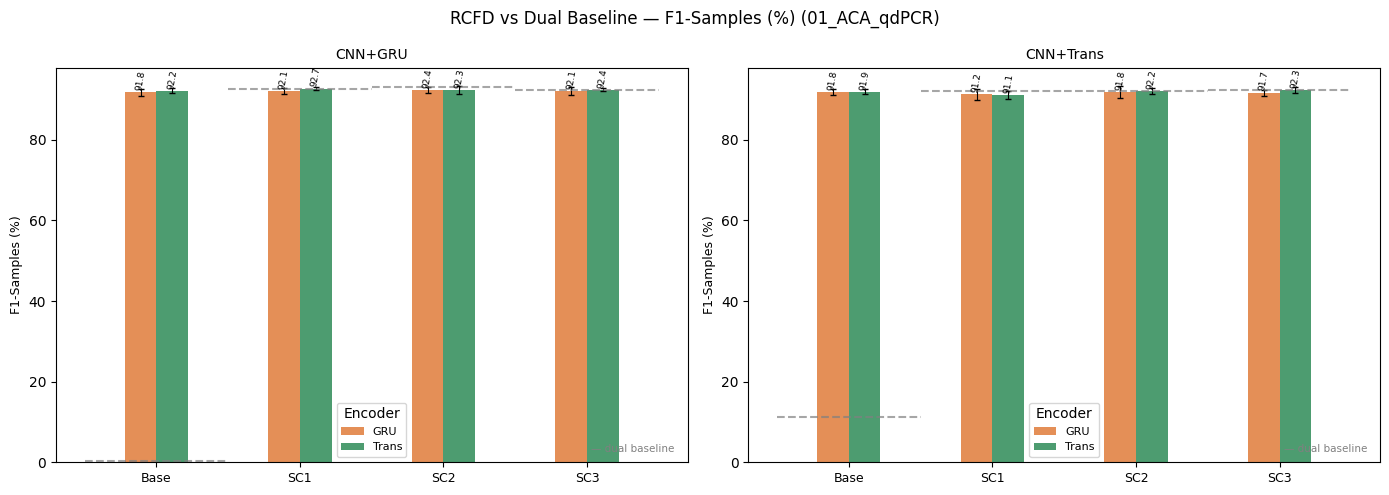

In [47]:
_RCFD_ENCS  = ['gru', 'trans']
_RCFD_DUALS = ['cgd', 'ctd']
_RCFD_ENC_LABELS  = {'gru': 'GRU', 'trans': 'Trans'}
_RCFD_DUAL_LABELS = {'cgd': 'CNN+GRU', 'ctd': 'CNN+Trans'}
_RCFD_ENC_COLORS  = {'gru': '#e07c39', 'trans': '#2e8b57'}
_RCFD_SC_VARIANTS = [('Base', 0), ('SC1', 1), ('SC2', 2), ('SC3', 3)]
_RCFD_DUAL_BASELINE = {'cgd': 'cnn_gru_dual', 'ctd': 'cnn_trans_dual'}


def plot_rcfd_vs_baseline(res_entry, metric='exact'):
    """RCFD accuracy vs SC-matched dual baseline; one panel per dual backbone."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)
    metric_label = {'exact': 'Exact Match (%)', 'hamming': 'Hamming (%)', 'f1s': 'F1-Samples (%)'}[metric]

    for ax, dual in zip(axes, _RCFD_DUALS):
        n_sc  = len(_RCFD_SC_VARIANTS)
        n_enc = len(_RCFD_ENCS)
        w     = 0.22
        x     = np.arange(n_sc)

        any_data = False
        for ei, enc in enumerate(_RCFD_ENCS):
            xs, ms, ss = [], [], []
            for si, (_, sc) in enumerate(_RCFD_SC_VARIANTS):
                key = f'{enc}_rcfd_{dual}' + ('_supcon_mtl' if sc==1 else '_supcon2_mtl' if sc==2 else '_supcon3_mtl' if sc==3 else '')
                if key not in ML_MODEL_KEY_MAP:
                    continue
                em, es, hm, f1m, f1s = _ml_metrics(res_entry, key)
                val = {'exact': (em, es), 'hamming': (hm, 0), 'f1s': (f1m, f1s)}[metric]
                if val[0] is None:
                    continue
                xs.append(si); ms.append(val[0]); ss.append(val[1] or 0)
                any_data = True

            if not ms:
                continue
            enc_offset = (ei - (n_enc - 1) / 2) * w
            bars = ax.bar(np.array(xs) + enc_offset, ms, w,
                          yerr=ss, label=_RCFD_ENC_LABELS[enc],
                          color=_RCFD_ENC_COLORS[enc], alpha=0.85,
                          capsize=2, error_kw={'linewidth': 0.8})
            for bar, mv in zip(bars, ms):
                ax.text(bar.get_x() + w / 2, mv + 0.2, f'{mv:.1f}',
                        ha='center', va='bottom', fontsize=6.5, rotation=80)

        # Baseline lines: SC-matched dual backbone
        bb_base = _RCFD_DUAL_BASELINE[dual]
        for si, (sc_label, sc) in enumerate(_RCFD_SC_VARIANTS):
            bb_key = _sc_key(bb_base, sc, False)
            if bb_key not in ML_MODEL_KEY_MAP:
                continue
            em, _, hm, f1m, _ = _ml_metrics(res_entry, bb_key)
            val = {'exact': em, 'hamming': hm, 'f1s': f1m}[metric]
            if val is not None:
                ax.hlines(val, si - 0.5, si + 0.5, colors='grey', ls='--', lw=1.5, alpha=0.7)

        ax.set_xticks(x)
        ax.set_xticklabels([s for s, _ in _RCFD_SC_VARIANTS], fontsize=9)
        ax.set_ylabel(metric_label, fontsize=9)
        ax.set_title(f'{_RCFD_DUAL_LABELS[dual]}', fontsize=10)
        if any_data:
            ax.legend(title='Encoder', fontsize=8)
        ax.text(0.98, 0.02, '— dual baseline', transform=ax.transAxes,
                ha='right', va='bottom', fontsize=7.5, color='grey')

    fig.suptitle(f'RCFD vs Dual Baseline — {metric_label} ({DATASET})', fontsize=12)
    plt.tight_layout()
    plt.show()


for metric in ['exact', 'f1s']:
    plot_rcfd_vs_baseline(res, metric=metric)

---
## Section 9 · Per-Label Confusion Matrices (best model)

---
## Section 10 · Combination Confusion Matrix (2^n_labels × 2^n_labels)

Each sample's label vector is encoded as an integer (bit 0 = KPC, bit 1 = NDM, bit 2 = VIM),
giving 2³ = 8 mutually exclusive combination classes.
The matrix shows how often each true combination is predicted as each other combination.

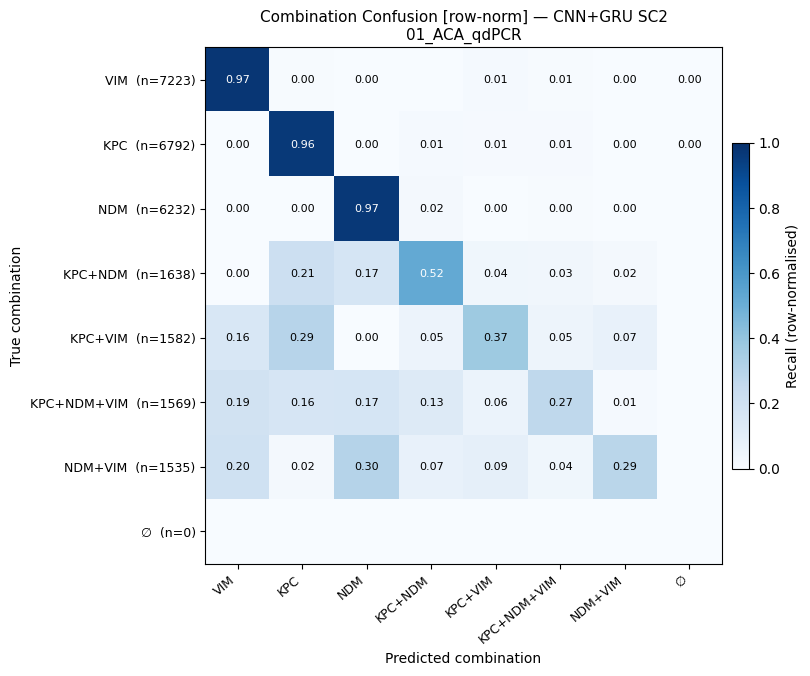

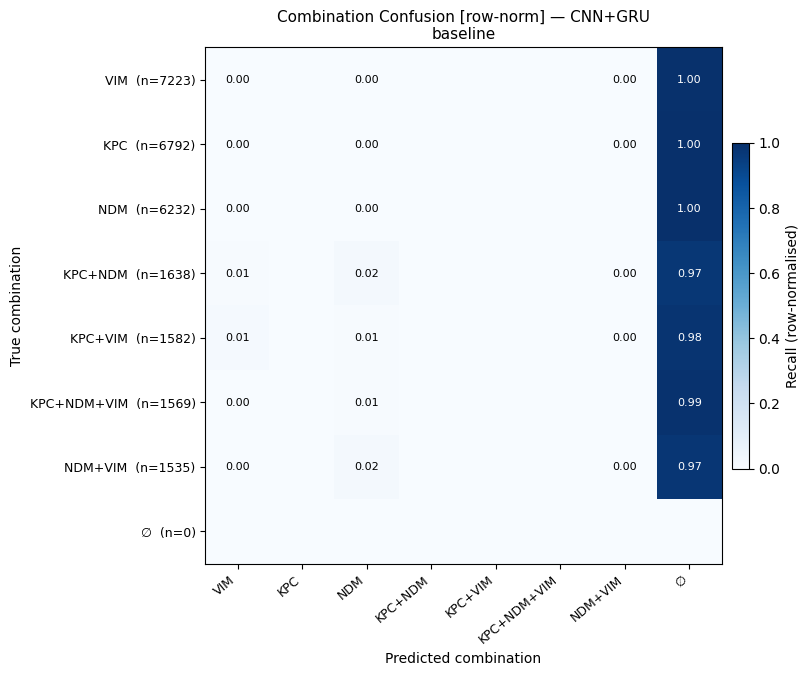

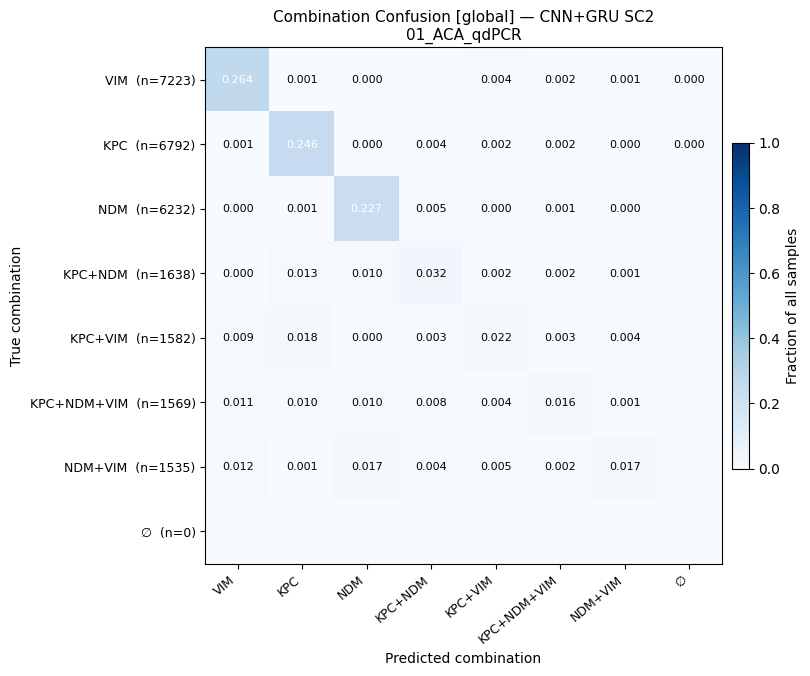

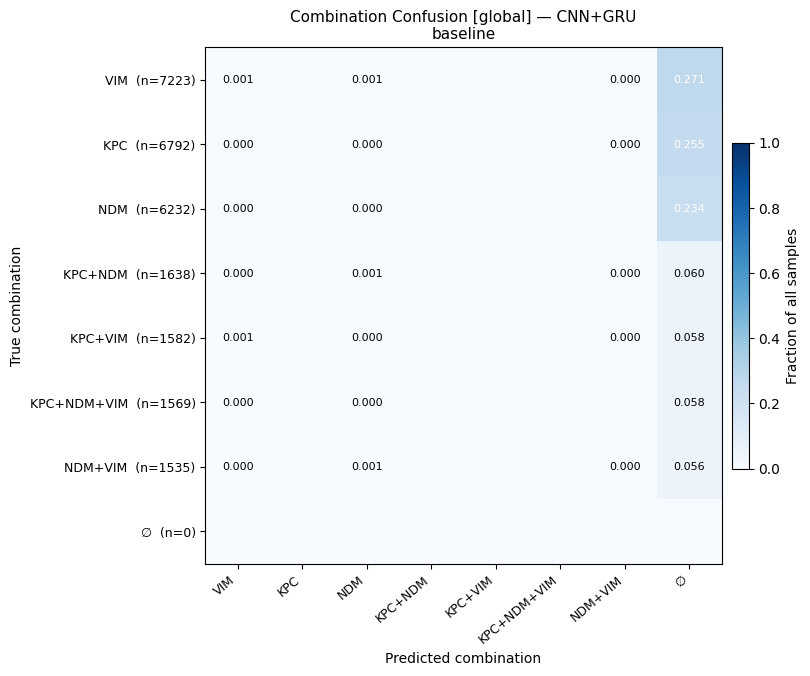

In [48]:
def _combo_labels(targets):
    """All 2^L combination strings in bit-index order (bit 0 = targets[0])."""
    L = len(targets)
    labels = []
    for idx in range(2 ** L):
        active = [targets[j] for j in range(L) if (idx >> j) & 1]
        labels.append('+'.join(active) if active else '∅')
    return labels


def _vec_to_idx(y):
    """Convert (N, L) binary array → (N,) integer combo index."""
    L = y.shape[1]
    powers = np.array([2 ** j for j in range(L)], dtype=np.int32)
    return (y.astype(np.int32) @ powers)


def plot_combination_confusion(res_entry, model_key, normalise='true', title=''):
    """2^L × 2^L confusion matrix over all label combinations.

    Parameters
    ----------
    normalise : 'true'  → rows sum to 1 (recall view)
                'pred'  → cols sum to 1 (precision view)
                'all'   → global fraction
                None    → raw counts
    """
    preds_key, _, _ = ML_MODEL_KEY_MAP[model_key]
    if preds_key not in res_entry:
        print(f'[!] {model_key} not in results'); return

    yt = np.concatenate(res_entry['y_trues_'],    axis=0).astype(np.int32)
    yp = np.concatenate(res_entry[preds_key], axis=0).astype(np.int32)

    n_classes   = 2 ** yt.shape[1]
    combo_lbls  = _combo_labels(TARGETS)

    yt_idx = _vec_to_idx(yt)
    yp_idx = _vec_to_idx(yp)

    # Build full n_classes × n_classes matrix (rows = true, cols = pred)
    cm = np.zeros((n_classes, n_classes), dtype=np.float64)
    for ti, pi in zip(yt_idx, yp_idx):
        cm[ti, pi] += 1

    # Normalise
    if normalise == 'true':
        row_sum = cm.sum(axis=1, keepdims=True)
        cm_plot = np.where(row_sum > 0, cm / row_sum, 0.0)
        fmt_str, cb_label = '.2f', 'Recall (row-normalised)'
    elif normalise == 'pred':
        col_sum = cm.sum(axis=0, keepdims=True)
        cm_plot = np.where(col_sum > 0, cm / col_sum, 0.0)
        fmt_str, cb_label = '.2f', 'Precision (col-normalised)'
    elif normalise == 'all':
        cm_plot = cm / cm.sum()
        fmt_str, cb_label = '.3f', 'Fraction of all samples'
    else:
        cm_plot = cm.copy()
        fmt_str, cb_label = '.0f', 'Count'

    # Sort classes by prevalence in y_true so rare combos go to the bottom
    true_counts  = cm.sum(axis=1)
    order        = np.argsort(true_counts)[::-1]
    cm_sorted    = cm_plot[np.ix_(order, order)]
    lbl_sorted   = [combo_lbls[i] for i in order]
    cnt_sorted   = true_counts[order].astype(int)
    ylabels      = [f'{l}  (n={n})' for l, n in zip(lbl_sorted, cnt_sorted)]

    fig, ax = plt.subplots(figsize=(max(7, n_classes * 0.9 + 1),
                                    max(6, n_classes * 0.9 + 1)))
    im = ax.imshow(cm_sorted, cmap='Blues', vmin=0,
                   vmax=1.0 if normalise else cm_sorted.max())
    plt.colorbar(im, ax=ax, label=cb_label, fraction=0.03, pad=0.02)

    ax.set_xticks(range(n_classes))
    ax.set_xticklabels(lbl_sorted, rotation=40, ha='right', fontsize=9)
    ax.set_yticks(range(n_classes))
    ax.set_yticklabels(ylabels, fontsize=9)
    ax.set_xlabel('Predicted combination', fontsize=10)
    ax.set_ylabel('True combination', fontsize=10)

    # Annotate each cell
    thresh = cm_sorted.max() * 0.5
    for i in range(n_classes):
        for j in range(n_classes):
            v = cm_sorted[i, j]
            if v == 0 and normalise:
                continue
            txt = f'{v:{fmt_str}}'
            ax.text(j, i, txt, ha='center', va='center',
                    fontsize=8, color='white' if v > thresh else 'black')

    model_label = ML_MODEL_PRINT_MAP.get(model_key, model_key)
    norm_str    = {'true': 'row-norm', 'pred': 'col-norm', 'all': 'global', None: 'counts'}[normalise]
    ax.set_title(f'Combination Confusion [{norm_str}] — {model_label}\n{title or DATASET}',
                 fontsize=11)
    plt.tight_layout()
    plt.show()


# Row-normalised (recall view) for best model and CNN+GRU baseline
for norm in ('true', 'all'):
    plot_combination_confusion(res, best_key, normalise=norm)
    if 'cnn_gru_dual' in ML_MODEL_KEY_MAP and ML_MODEL_KEY_MAP['cnn_gru_dual'][0] in res:
        plot_combination_confusion(res, 'cnn_gru_dual', normalise=norm, title='baseline')

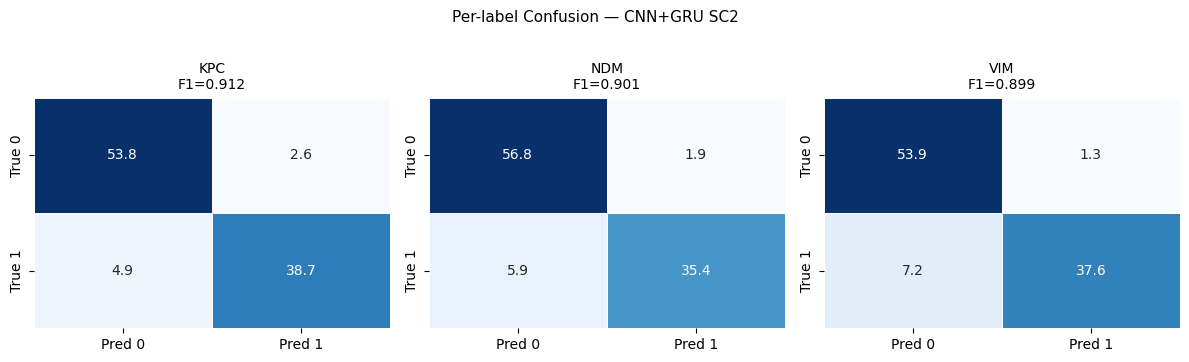

In [49]:
def plot_multilabel_confusion(res_entry, model_key):
    """One 2×2 confusion matrix per target for the given model."""
    preds_key, _, _ = ML_MODEL_KEY_MAP[model_key]
    if preds_key not in res_entry:
        print(f'[!] {model_key} not in results'); return
    yt = np.concatenate(res_entry['y_trues_'],    axis=0)
    yp = np.concatenate(res_entry[preds_key], axis=0)

    cms = multilabel_confusion_matrix(yt, yp)  # (L, 2, 2)
    L   = len(TARGETS)

    fig, axes = plt.subplots(1, L, figsize=(4 * L, 3.5))
    if L == 1:
        axes = [axes]

    for ax, cm, target in zip(axes, cms, TARGETS):
        cm_pct = cm / cm.sum() * 100
        sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
                    xticklabels=['Pred 0', 'Pred 1'],
                    yticklabels=['True 0', 'True 1'],
                    ax=ax, cbar=False, linewidths=0.5)
        tn, fp, fn, tp = cm.ravel()
        f1 = 2*tp / (2*tp + fp + fn) if (2*tp + fp + fn) > 0 else 0
        ax.set_title(f'{target}\nF1={f1:.3f}', fontsize=10)

    model_label = ML_MODEL_PRINT_MAP.get(model_key, model_key)
    fig.suptitle(f'Per-label Confusion — {model_label}', fontsize=11, y=1.02)
    plt.tight_layout()
    plt.show()


plot_multilabel_confusion(res, best_key)